In [62]:
import math
import os
import random
import sys
from copy import copy
from dataclasses import dataclass

import matplotlib.pyplot as plt

WORLD_SIZE = 100


@dataclass(frozen=True)
class Point:
    x: float = 0.
    y: float = 0.

    def __post_init__(self) -> None:
        if not 0 <= self.x < WORLD_SIZE:
            raise ValueError(f'x = {self.x} is out of bounds')
        if not 0 <= self.y < WORLD_SIZE:
            raise ValueError(f'y = {self.y} is out of bounds')


@dataclass(frozen=True)
class Noise:
    forward: float = 0.
    turn: float = 0.
    sense: float = 0.


LANDMARKS = (Point(20., 20.), Point(20., 80.),
             Point(20., 50.), Point(50., 20.),
             Point(50., 80.), Point(80., 80.),
             Point(80., 20.), Point(80., 50.))


In [63]:
class RobotState:

    def __init__(self, point: Point = None, angle: float = None,
                 noise: Noise = None) -> None:
        self.point = point if point else Point(random.random() * WORLD_SIZE,
                                               random.random() * WORLD_SIZE)
        self._noise = noise if noise else Noise(0., 0., 0.)

        if angle:
            if not 0 <= angle <= 2 * math.pi:
                raise ValueError(f'Angle must be within [{0.}, {2 * math.pi}, '
                                 f'the given value is {angle}]')
        self.angle = angle if angle else random.random() * 2.0 * math.pi

    @property
    def point(self) -> Point:
        return self._point

    @point.setter
    def point(self, point: Point) -> None:
        self._point = point

    @property
    def angle(self) -> float:
        return self._angle

    @angle.setter
    def angle(self, value: float) -> None:
        self._angle = float(value)

    def __str__(self) -> str:
        x, y = self.point.x, self.point.y
        return f'x = {x:.3f} y = {y:.3f} angle = {self.angle:.3f}'

    def __copy__(self) -> 'RobotState':
        return type(self)(self.point, self.angle, self._noise)

    def _distance(self, landmark: Point) -> float:
      x, y = self.point.x, self.point.y
      dist = (x - landmark.x) ** 2 + (y - landmark.y) ** 2
      return math.sqrt(dist)

    def sense(self) -> list[float]:
      return [self._distance(x) + random.gauss(.0, self._noise.sense)
              for x in LANDMARKS]

    def move(self, turn: float, forward: float) -> None:
      if forward < 0.:
          raise ValueError('RobotState cannot move backwards')

      # turn, and add randomness to the turning command
      angle = self._angle + turn + random.gauss(0., self._noise.turn)
      angle %= 2 * math.pi

      # move, and add randomness to the motion command
      gain = forward + random.gauss(0., self._noise.forward)
      x = self.point.x + math.cos(angle) * gain
      y = self.point.y + math.sin(angle) * gain

      self.point = Point(x % WORLD_SIZE, y % WORLD_SIZE)
      self.angle = angle

    @staticmethod
    def gaussian(mu: float, sigma: float, x: float) -> float:
        var = sigma ** 2
        numerator = math.exp(-((x - mu) ** 2) / (2 * var))
        denominator = math.sqrt(2 * math.pi * var)
        return numerator / (denominator + sys.float_info.epsilon)


    def meas_probability(self, measurement: list[float]) -> float:
      prob = 1.
      for ind, landmark in enumerate(LANDMARKS):
          dist = self._distance(landmark)
          prob *= self.gaussian(dist, self._noise.sense, measurement[ind])
      return prob


    def robot_playground() -> None:
      robot = RobotState(Point(30., 50.), math.pi / 2., Noise(5., .1, 5.))
      print(robot)
      print(robot.sense())

      # clockwise turn and move
      robot.move(-math.pi / 2., 15.)
      print(robot)
      print(robot.sense())

      # clockwise turn again and move
      robot.move(-math.pi / 2., 10.)
      print(robot)
      print(robot.sense())

In [64]:
robot = RobotState()

n = 1000
particles = [RobotState(noise=Noise(0.05, 0.05, 5.)) for _ in range(n)]

In [65]:
steps = 50
for step in range(steps):
    robot.move(.1, 5.)
    meas = robot.sense()

    for p in particles:
        p.move(.1, 5.)

In [66]:
weights = [p.meas_probability(meas) for p in particles]

In [67]:
particles_resampled = []
index = int(random.random() * n)
beta = 0.

for _ in range(n):
    beta += random.random() * 2. * max(weights)
    while beta > weights[index]:
        beta -= weights[index]
        index = (index + 1) % n
    particles_resampled.append(copy(particles[index]))

In [68]:
def evaluation(robot: RobotState, particles: list[RobotState]) -> float:
    sum_ = 0.
    x, y = robot.point.x, robot.point.y
    for particle in particles:
        dx = (particle.point.x - x + (WORLD_SIZE / 2.)) % WORLD_SIZE - (
            WORLD_SIZE / 2.)
        dy = (particle.point.y - y + (WORLD_SIZE / 2.)) % WORLD_SIZE - (
            WORLD_SIZE / 2.)
        err = math.sqrt(dx ** 2 + dy ** 2)
        sum_ += err

    return sum_ / len(particles)

In [69]:
particles = particles_resampled
print(f'step {step}, evaluation: {evaluation(robot, particles):.3f}')

step 49, evaluation: 3.031


In [70]:
def visualization(robot: RobotState, step: int, particles: list[RobotState],
                  particles_resampled: list[RobotState]) -> None:
    plt.figure("Robot in the world", figsize=(15., 15.))
    plt.title('Particle filter, step ' + str(step))

    # draw coordinate grid for plotting
    grid = [0, WORLD_SIZE, 0, WORLD_SIZE]
    plt.axis(grid)
    plt.grid(visible=True, which='major', color='0.75', linestyle='--')
    plt.xticks(range(0, int(WORLD_SIZE), 5))
    plt.yticks(range(0, int(WORLD_SIZE), 5))

    def draw_circle(x_: float, y_: float, face: str, edge: str,
                    alpha: float = 1.) -> None:
        circle = plt.Circle(
            (x_, y_), 1., facecolor=face, edgecolor=edge, alpha=alpha)
        plt.gca().add_patch(circle)

    def draw_arrow(x_: float, y_: float, face: str, edge: str,
                   alpha: float = 1.) -> None:
        arrow = plt.Arrow(x_, y_, 2 * math.cos(particle.angle),
                          2 * math.sin(particle.angle), facecolor=face,
                          edgecolor=edge, alpha=alpha)
        plt.gca().add_patch(arrow)

    # draw particles
    for particle in particles:
        x, y = particle.point.x, particle.point.y
        draw_circle(x, y, '#ffb266', '#994c00', 0.5)
        draw_arrow(x, y, '#994c00', '#994c00')

    # draw resampled particles
    for particle in particles_resampled:
        x, y = particle.point.x, particle.point.y
        draw_circle(x, y, '#66ff66', '#009900', 0.5)
        draw_arrow(x, y, '#006600', '#006600')

    # draw landmarks
    for landmark in LANDMARKS:
        draw_circle(landmark.x, landmark.y, '#cc0000', '#330000')

    # robot's location and angle
    draw_circle(robot.point.x, robot.point.y, '#6666ff', '#0000cc')
    draw_arrow(robot.point.x, robot.point.y, '#000000', '#000000', 0.5)

    plt.savefig(os.path.join('output', 'figure_' + str(step) + '.png'))
    plt.show()
    plt.close()

step 0, evaluation: 4.728


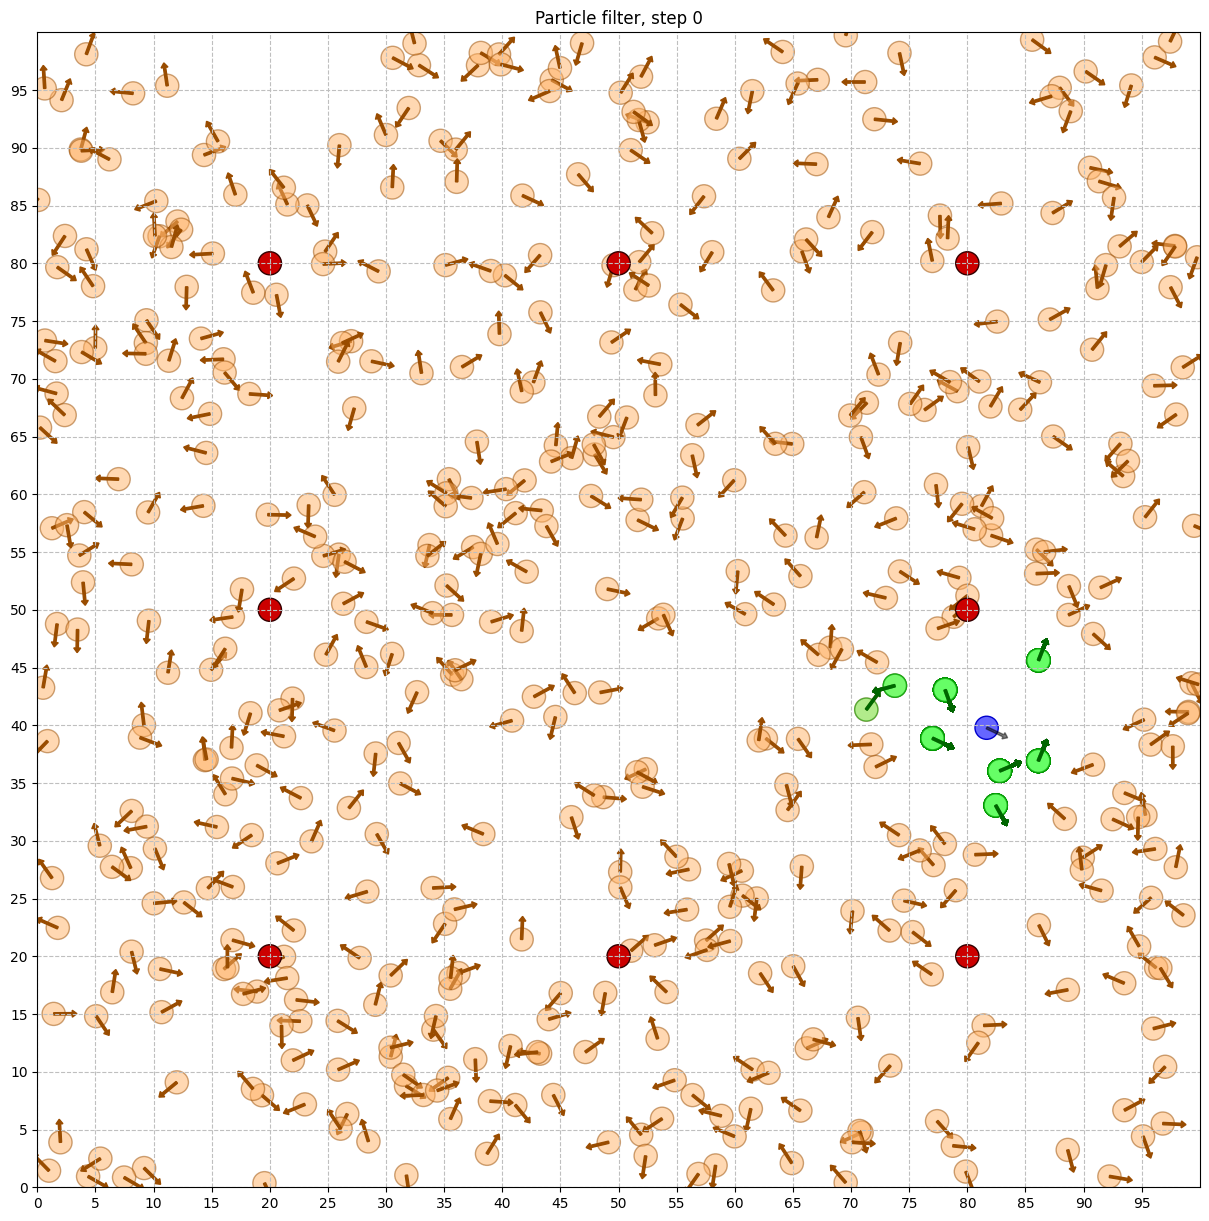

step 1, evaluation: 2.216


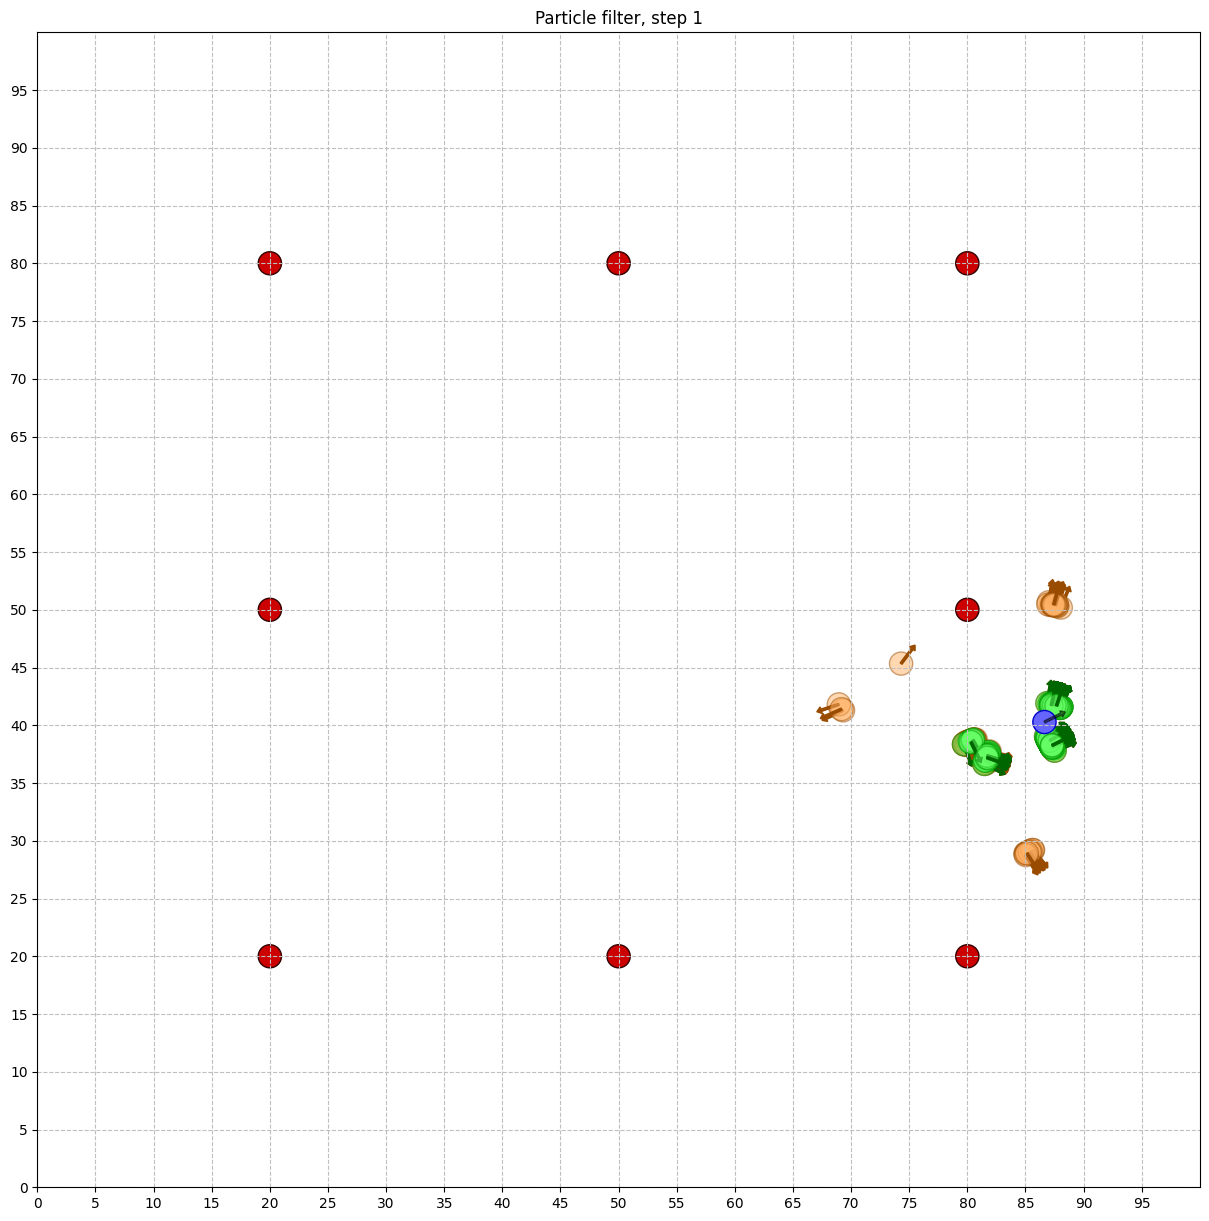

step 2, evaluation: 0.619


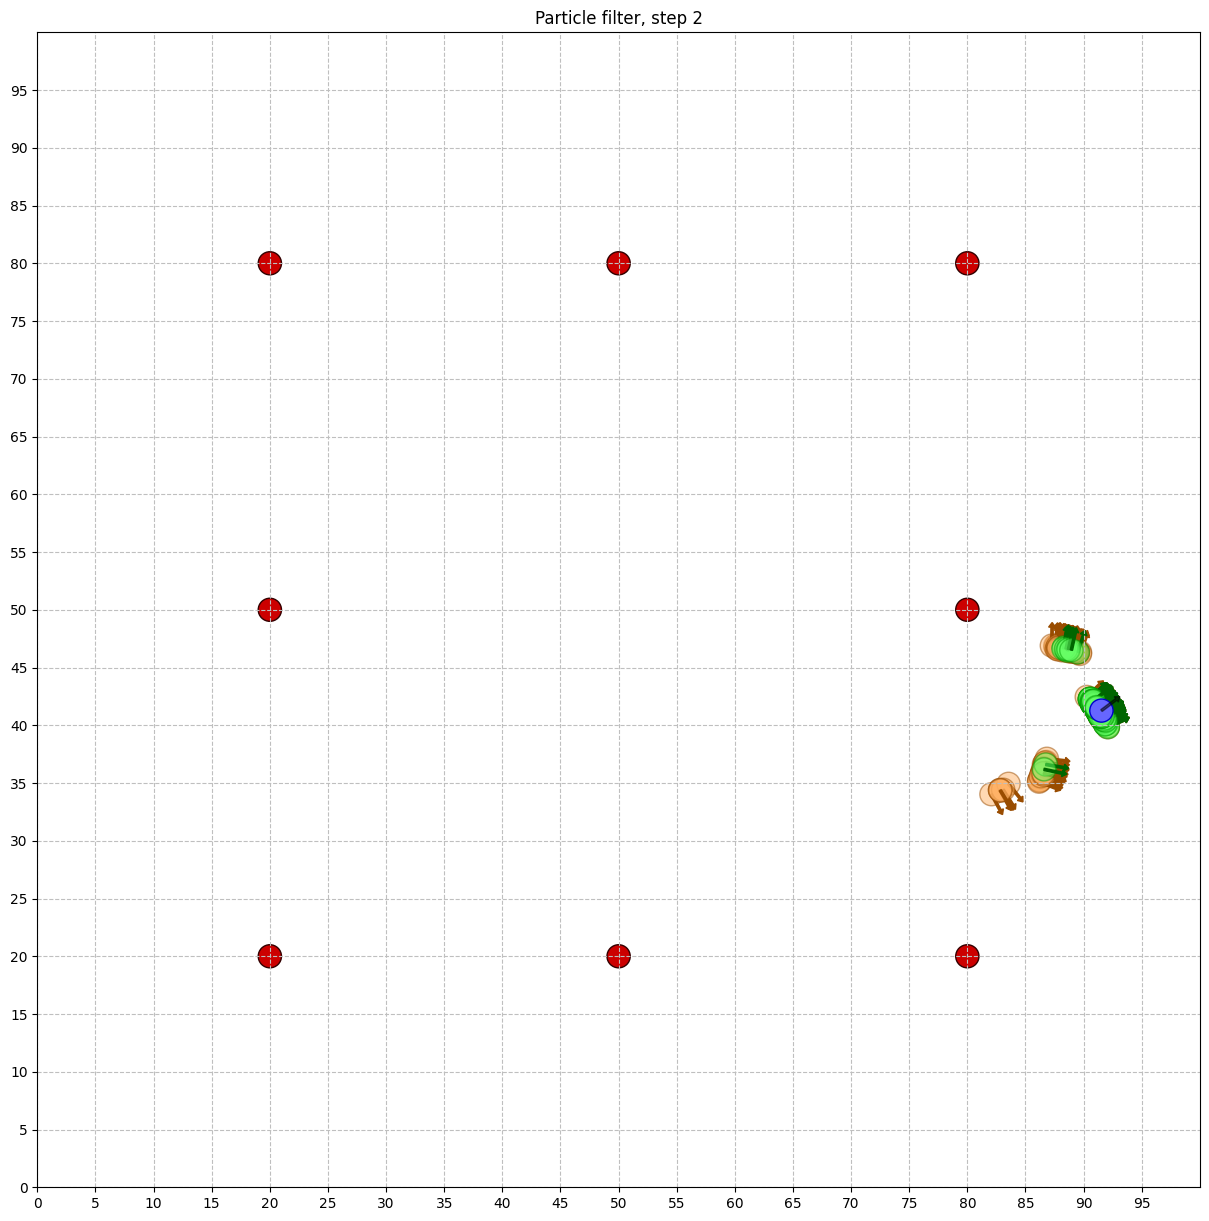

step 3, evaluation: 1.882


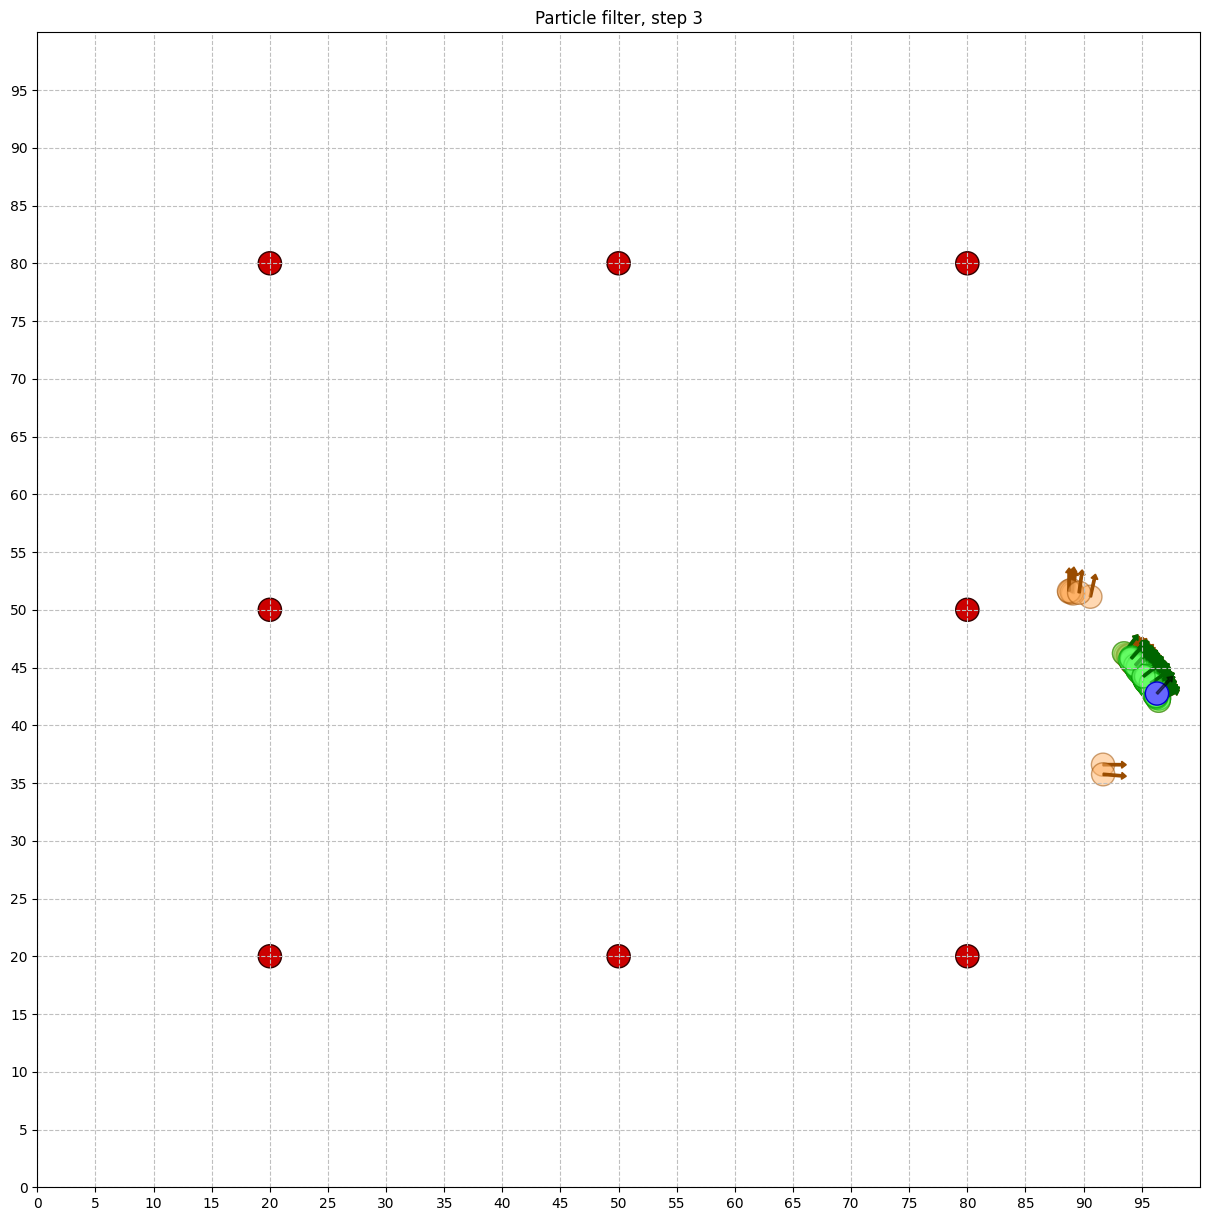

step 4, evaluation: 1.174


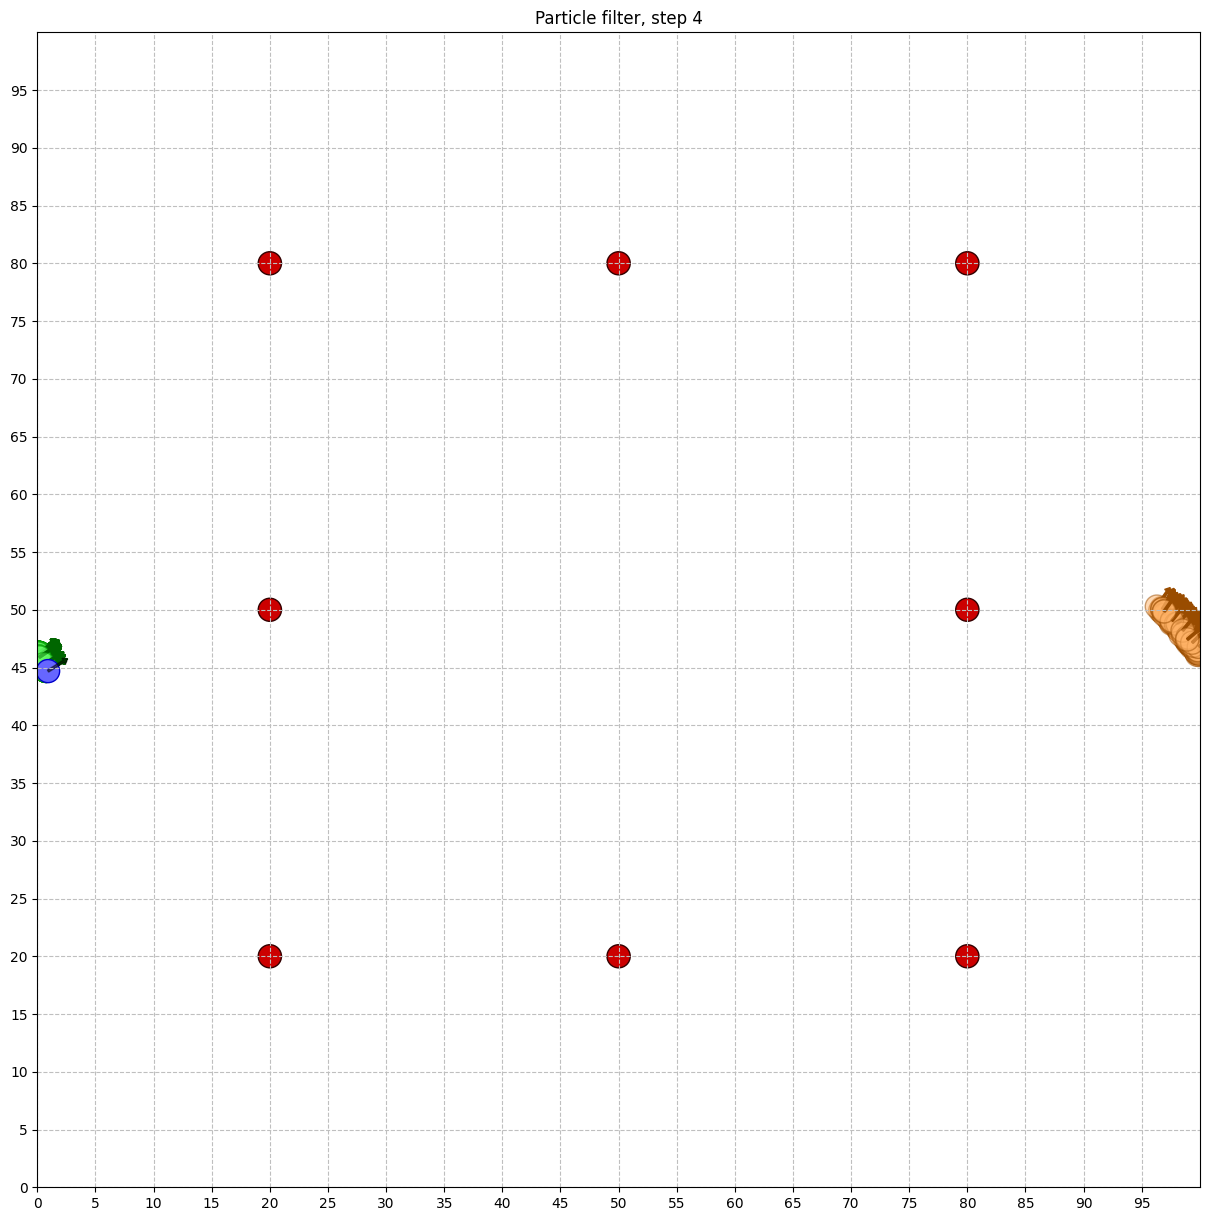

step 5, evaluation: 1.997


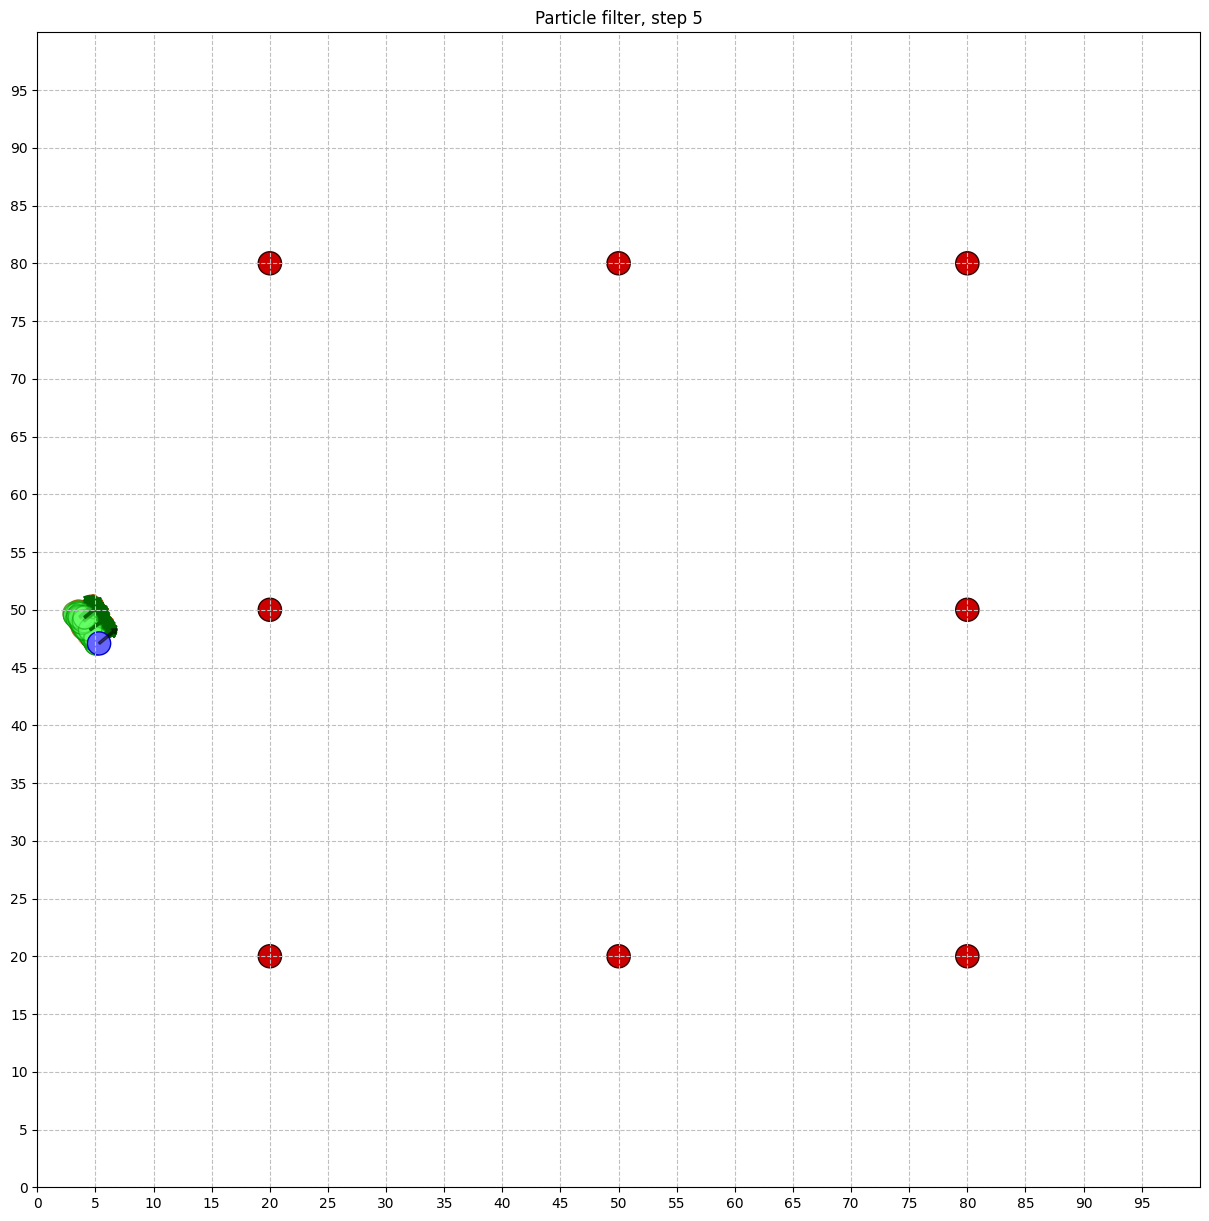

step 6, evaluation: 2.474


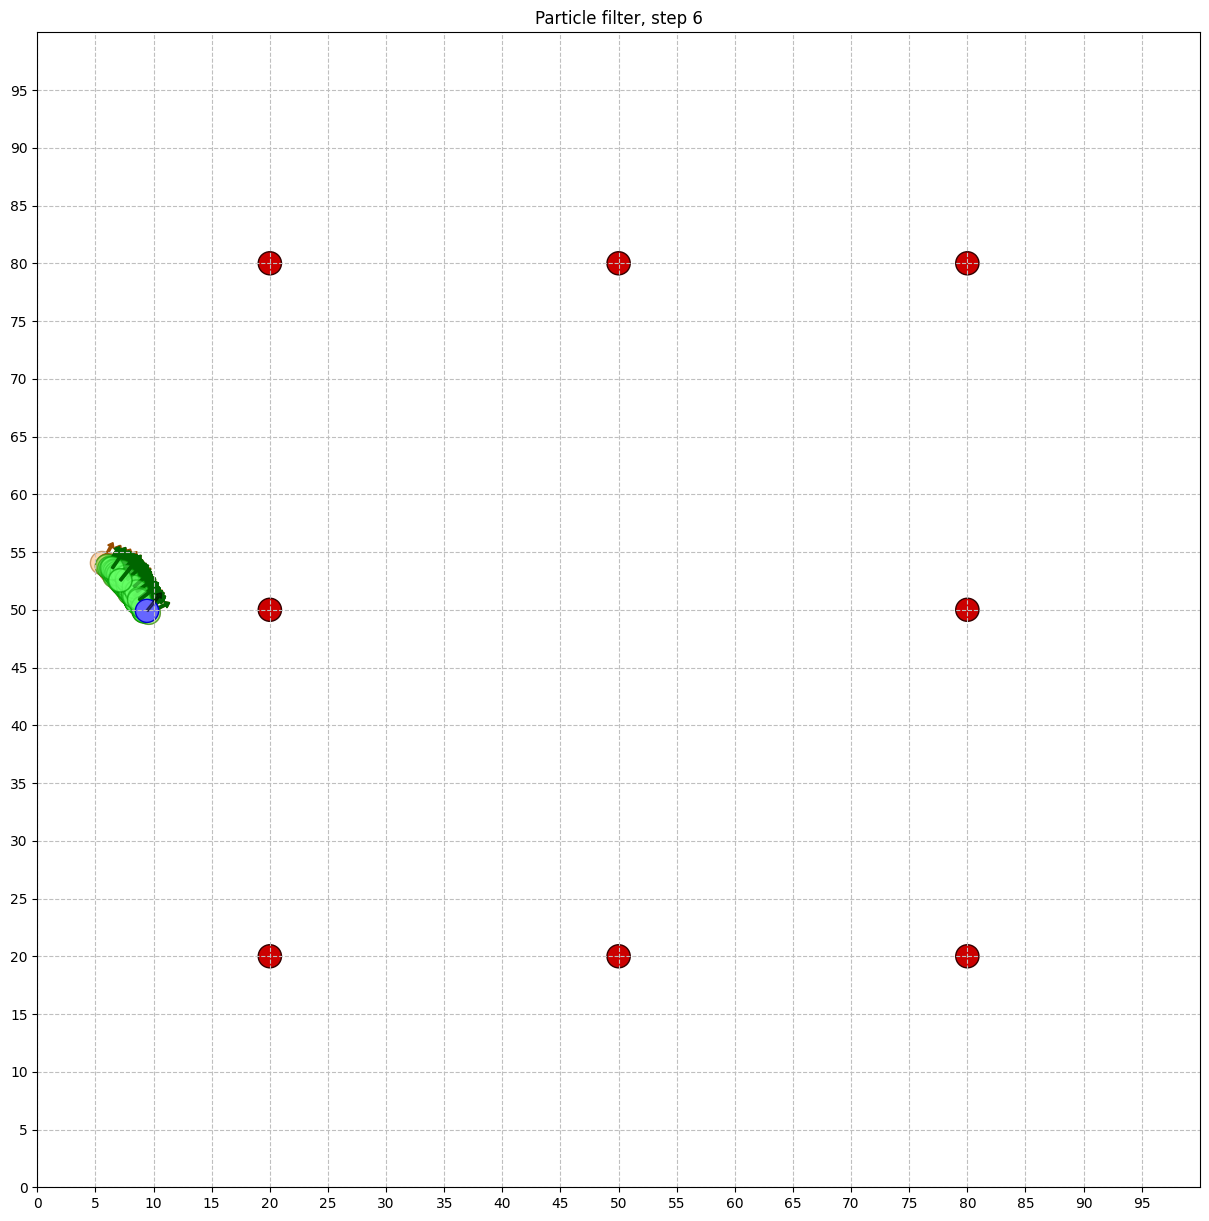

step 7, evaluation: 2.184


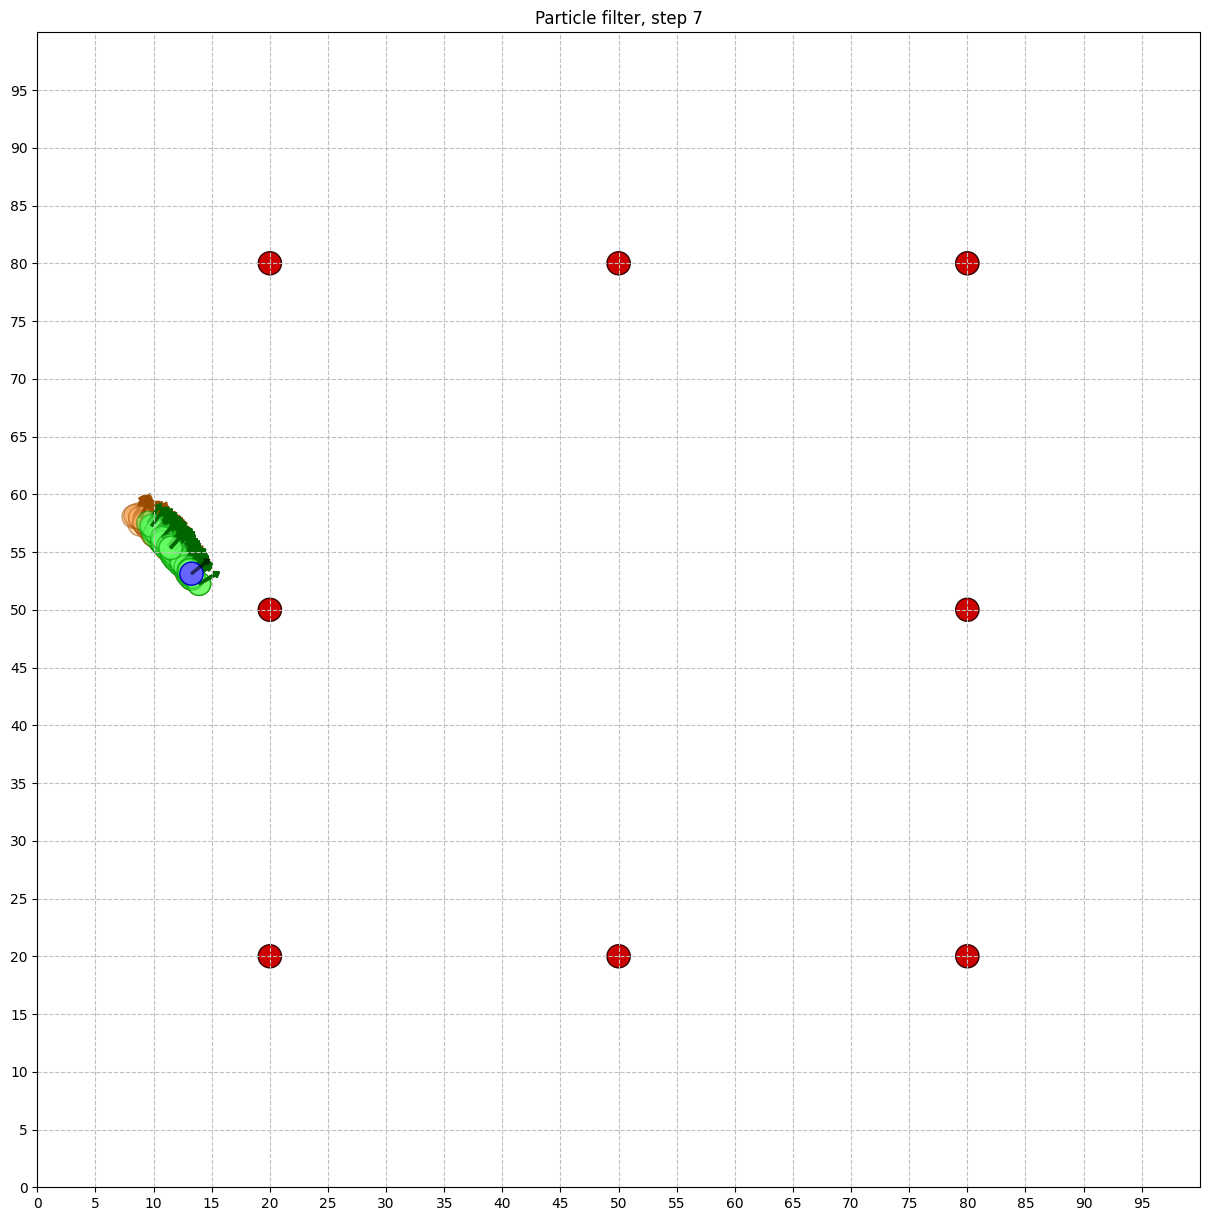

step 8, evaluation: 1.776


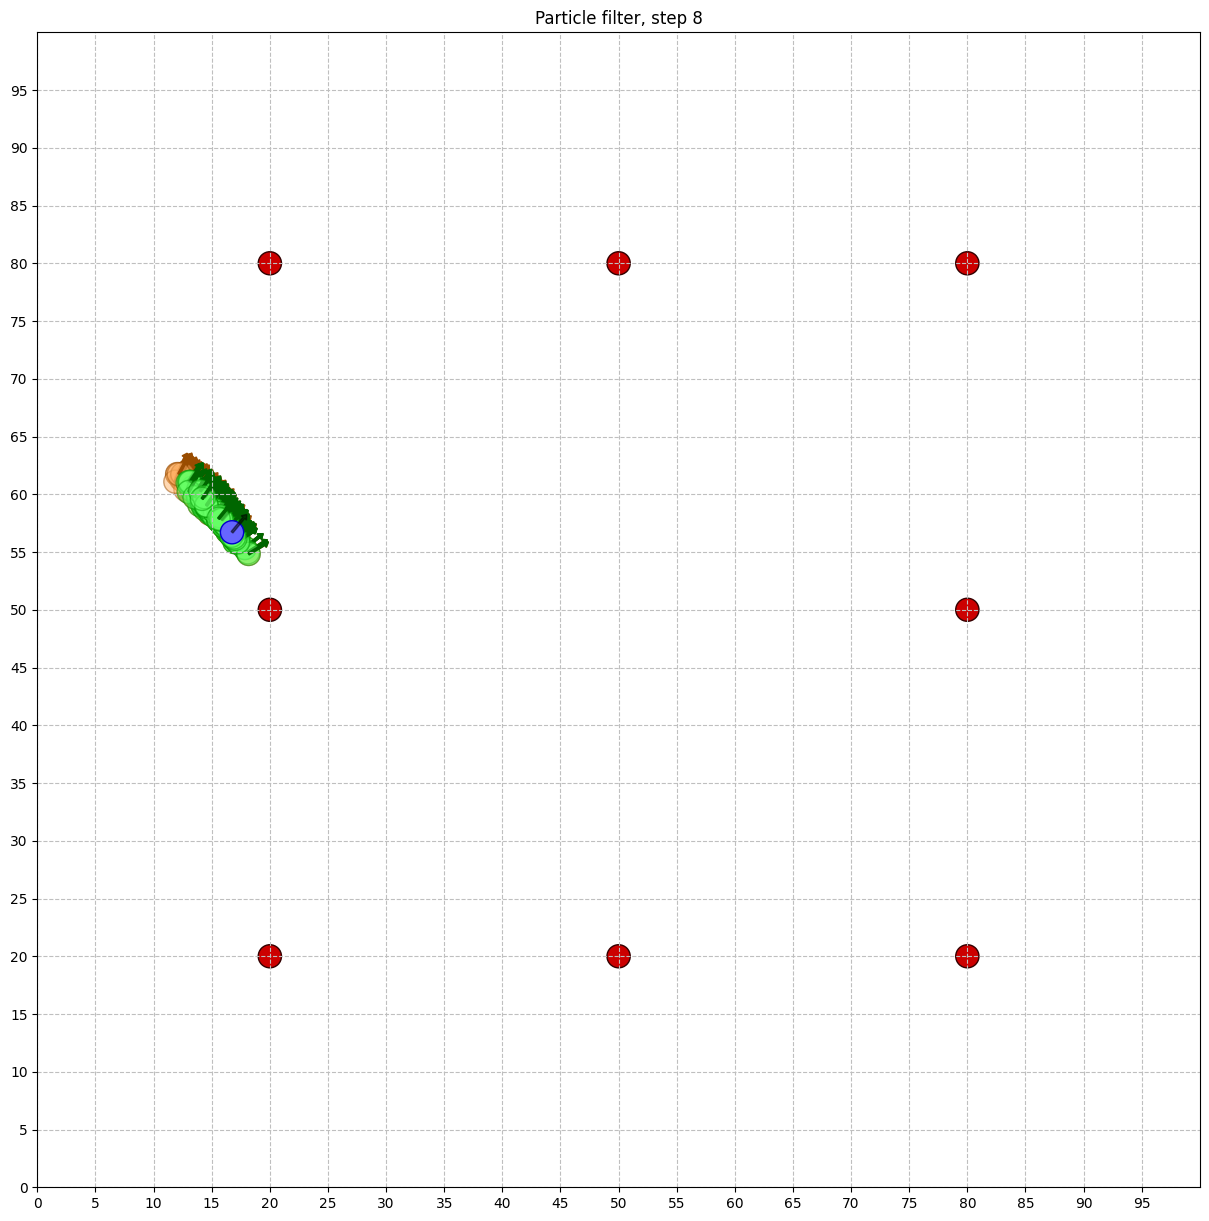

step 9, evaluation: 1.538


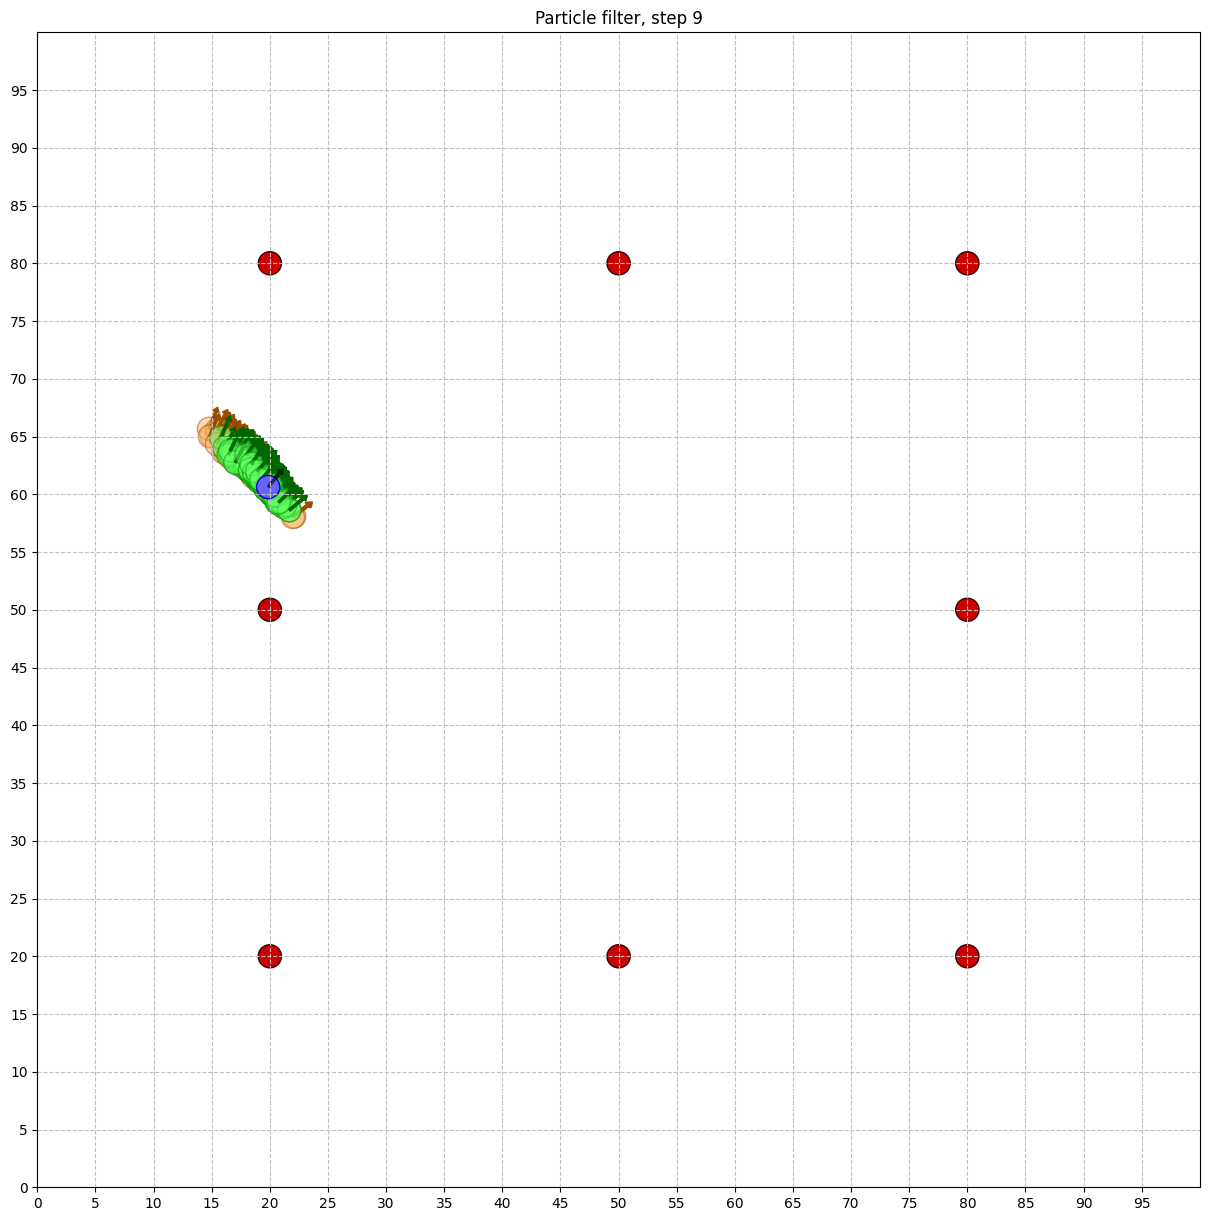

In [71]:
import os
from copy import copy
import random

# (Необязательно) Зафиксируем seed, чтобы каждый раз была одинаковая случайная картинка.
# Закомментируйте строку ниже, если хотите, чтобы позиции и шум каждый раз были разными.
# random.seed(42)

# Создадим папку для сохранения результатов визуализации.
os.makedirs('output', exist_ok=True)

# Инициализируем "настоящего" робота в случайном месте
robot = RobotState()

# Создаём «хаотический» набор частиц в случайных местах (каждая со своим шумом)
n = 500
particles = [RobotState(noise=Noise(0.05, 0.05, 5.)) for _ in range(n)]

# Количество шагов, которое делаем
steps = 10

for step in range(steps):
    # Шаг робота
    robot.move(0.1, 5.0)
    meas = robot.sense()

    # Движение частиц
    for p in particles:
        p.move(0.1, 5.0)

    # Считаем «вес» каждой частицы по полученному роботом измерению
    weights = [p.meas_probability(meas) for p in particles]

    # Ресэмплинг (метод «колеса» Себастьяна Трана)
    particles_resampled = []
    index = int(random.random() * n)
    beta = 0.
    mw = max(weights)
    for _ in range(n):
        beta += random.random() * 2.0 * mw
        while beta > weights[index]:
            beta -= weights[index]
            index = (index + 1) % n
        particles_resampled.append(copy(particles[index]))

    # Метрика «качества» оценки: средняя ошибка частиц относительно робота
    print(f"step {step}, evaluation: {evaluation(robot, particles_resampled):.3f}")

    # Визуализация (сохраняет картинки в папку 'output')
    visualization(robot, step, particles, particles_resampled)

    # Обновляем набор частиц после ресэмплинга
    particles = particles_resampled
